# Lab 2.1 — The data foundation

**What this notebook does:** builds the whole world the rest of the course
runs on — twenty data tables describing **three years of trading across
twenty-seven selling locations** at a fictional travel-money business — and
writes them to `data/` as CSV files.

**Run this notebook first, top to bottom.** Every other notebook loads these
tables. It takes about a minute.

---

## Why we build the data instead of downloading it

Every pricing lesson worth learning is a lesson about **cause and effect**:
*if I raise the price by one point, what happens to volume, revenue and
profit?* With real data you can never check your answer. You estimate an
elasticity of −9%, and… that's it. Nobody hands you the true number.

Here you get the true number. This notebook *writes down the rules the world
obeys* — how customers choose a channel, how they decide to buy, how
competitors move, how our own pricing desk sets rates — and then simulates
three years of trading under those rules. The rules are saved in
`data/truth.json`, the **answer key**.

So the course works like this:

1. You analyse the data exactly as you would at work — messy, confounded,
   incomplete.
2. You produce an estimate.
3. You open the answer key and see how close you were.

That third step is what no real job gives you, and it is the fastest way to
develop judgement about *which methods can be trusted when*.

**A warning that matters.** Simulated data is honest about one thing and
dishonest about another. Honest: it will show you exactly how a technique
behaves when its assumptions hold and how it breaks when they don't.
Dishonest: real customers are stranger than any equation. Never conclude
"elasticity is −9%" about the world from a notebook. Conclude "*this method*
recovers the truth when *these* conditions hold" — that transfers.

## The business: Meridian FX

Meridian FX sells foreign currency to UK travellers.

- **24 high-street branches** across **12 regions** (two per region), plus
  **two airport kiosks** (Heathrow and Gatwick), plus one **online** channel
  serving the whole country. Twenty-seven locations, three channels.
- **Three products** — euro cash, US dollar cash, and a multi-currency
  prepaid travel card — and online orders arrive two ways: **home delivery**
  by insured courier, or **click & collect** at a branch.
- **How it earns:** we buy currency wholesale at the *mid-market rate* and
  sell it to the customer at a worse rate. The gap is the **margin**, quoted
  in **percentage points (pp)** of the order value. Sell someone £500 of
  euros at a 3.5pp margin and we book £17.50 of revenue.
- **What it pays out:** funding, card acquiring, counter time, secure
  transport, courier — and a **commission to the host retail network on
  every branch sale**, which turns out to matter more than any of them.

Three structural features make this business able to teach the whole
subject rather than one corner of it:

| Feature | Why it is here |
|---|---|
| **Regions with two branches each** | Regions are the unit a geo experiment randomises. Twelve of them makes real geo testing possible ([the omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb)) |
| **Customers choose their channel** | Change the online-versus-branch price gap and customers move. That is *cannibalisation*, and it is the hardest thing in omnichannel pricing to measure |
| **Customers come back — or don't** | A customer who is quietly overcharged for a year returns less often the next. Price affects lifetime value, not just today's order |

Pick any pricing job — retail, insurance, SaaS, airlines — and the
*structure* of the problem is the same; only the vocabulary changes.

## Data fundamentals — the four ideas you need before any pricing analysis

Before the code, four concepts. Nearly every wrong pricing number I have
ever seen traces back to one of these being fumbled.

### 1. Grain

The **grain** of a table is what exactly one row means. Not roughly — exactly.

| Table | One row is… |
|---|---|
| `fct_quotes` | one customer shopping for currency, on one day, in one channel, for one product |
| `fct_transactions` | one order that was actually paid for |
| `fct_daily` | one day × one site × one product |
| `fct_region_week` | one region × one week, all channels combined — **the geo-test panel** |
| `fct_price_board` | the rate we advertised on one day × pricing zone × product |

If you cannot say the grain of your table in one sentence, you cannot
compute an average safely, because you don't know what you are averaging
*over*. "Average margin" at quote grain and "average margin" at transaction
grain are **different numbers** (see the mix trap in [lab 4.1](../04_satisfy_the_regulator/lab_01_segmentation_and_fairness.ipynb)), and
picking the wrong one has cost real companies real money.

### 2. Facts and dimensions

- **Fact tables** (`fct_*`) record *events with numbers*: quotes, orders,
  daily totals. They are long, and they grow every day.
- **Dimension tables** (`dim_*`) record *the things events refer to*:
  customers, sites, regions, products. They are short and change slowly.

Facts join to dimensions on keys (`site_id`, `region_id`, `product_id`,
`customer_id`). This is the standard warehouse layout you will meet in any
commercial data team, and it exists so nobody has to re-type "Manchester
Arndale, North West" onto half a million rows.

### 3. The events you *don't* see

This is the pricing-specific one, and it is the difference between an
analyst and a good analyst.

- **Quotes vs sales.** The till records the customer who bought. It does not
  record the customer who looked at your rate, made a face and walked out.
  We record both here — most businesses don't, and the ones that do have a
  large advantage.
- **Censoring.** When a branch runs out of euro notes, sales stop — not
  because demand stopped. Sales are then a *floor* on demand, not a
  measurement of it. ([Lab 1.4](../01_set_the_rate/lab_04_competition_and_dynamics.ipynb).)
- **Selection.** Customers choose which channel to use, and that choice
  depends on the prices they see. Compare channels naively and you will
  "discover" an effect that is mostly who walked in the door.
- **The customer who did not come back.** The most expensive number in
  pricing is never in the data at all.

### 4. The answer key exists only here

`truth.json` holds the parameters that generated everything: the true
sensitivity of each segment, the true channel-switching parameter, the true
effects of the experiment and the promotion, the true volume lost to
stockouts, the true lifetime cost of overcharging, and the profit-maximising
margins. **Do not read it before you attempt an estimate.**

---

Everything below is plumbing. Read the markdown between the code cells —
it explains the structure of the world you are about to analyse, and several
of the lessons later depend on knowing how a piece of it was built.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 20260726
rng = np.random.default_rng(SEED)

# The shared data folder at the root of workspace/pricing — found by walking up,
# so this notebook writes to the same place every other lesson reads from.
DATA = next(f / "data" for f in [Path.cwd(), *Path.cwd().parents] if (f / "engine").is_dir())
DATA.mkdir(exist_ok=True)

START, END = "2023-01-01", "2025-12-31"
dates = pd.date_range(START, END, freq="D")
N_DAYS = len(dates)
YEARS = sorted(dates.year.unique())

# Key events the lessons rely on -------------------------------------------
EXP_START, EXP_END = pd.Timestamp("2025-03-03"), pd.Timestamp("2025-04-27")   # the online A/B test
PROMO_START, PROMO_END = pd.Timestamp("2025-06-02"), pd.Timestamp("2025-08-31")  # the summer promo
PROMO_REGIONS = ["R01", "R02", "R03", "R06"]
TRIAL_START, TRIAL_END = pd.Timestamp("2024-09-02"), pd.Timestamp("2024-10-13")  # last year's bad trial
TRIAL_REGIONS = ["R05", "R09"]

print(f"{N_DAYS} days of trading: {dates[0]:%d %b %Y} to {dates[-1]:%d %b %Y}")

1096 days of trading: 01 Jan 2023 to 31 Dec 2025


## Step 1 — the calendar

Seasonality is the single largest force in this business and the single
largest source of wrong answers. Travel money follows school holidays: an
enormous August peak, smaller bumps at Easter, February half-term (ski),
October half-term and Christmas.

Two columns matter later:

- `season_index` — a demand multiplier. 1.0 is an average day; 1.75 means
  three-quarters more people are shopping.
- `season_z` — the same thing standardised (mean 0, standard deviation 1),
  which is easier to read as a regression coefficient.

The calendar also carries `funding_cost_bp`: what it costs *us*, in basis
points, to source currency wholesale that day. It drifts, and occasionally
jumps when wholesale markets get stressed. Remember this column — in
[lab 2.5](lab_05_causal_inference.ipynb) it becomes an **instrument**, and a flawed one, which turns out
to be more instructive than a clean one.

> **Basis points (bp).** One basis point = 0.01 percentage points. A margin
> of 3.50pp is 350bp. Pricing desks speak in bp because the decisions are
> small: "let's take 15bp off the euro rate" is a normal sentence, and
> "let's take 0.15 percentage points off" is not.

In [2]:
def bump(day_of_year, centre, width, height):
    """A smooth seasonal hump centred on a day of the year."""
    return height * np.exp(-0.5 * ((day_of_year - centre) / width) ** 2)


cal = pd.DataFrame({"date": dates})
cal["dow"] = cal["date"].dt.dayofweek                      # 0 = Monday
cal["day_name"] = cal["date"].dt.day_name()
cal["month"] = cal["date"].dt.month
cal["year"] = cal["date"].dt.year
cal["iso_week"] = cal["date"].dt.isocalendar().week.astype(int)

doy = cal["date"].dt.dayofyear.to_numpy()
season = (1.00
          + bump(doy, 213, 40, 0.75)    # the summer holiday peak, early August
          + bump(doy, 100, 14, 0.25)    # Easter
          + bump(doy, 46, 8, 0.12)      # February half-term (ski trips)
          + bump(doy, 300, 9, 0.12)     # October half-term
          + bump(doy, 359, 11, 0.20))   # Christmas and New Year
cal["season_index"] = season.round(4)
cal["season_z"] = ((season - season.mean()) / season.std()).round(4)

school_windows = [(1, 4), (42, 49), (88, 102), (145, 152), (200, 245), (296, 303), (354, 366)]
is_holiday = np.zeros(N_DAYS, dtype=bool)
for first, last in school_windows:
    is_holiday |= (doy >= first) & (doy <= last)
cal["school_holiday"] = is_holiday.astype(int)

# Wholesale funding cost: mean-reverting, with four market-stress episodes.
funding = np.empty(N_DAYS)
funding[0] = 22.0
shock = rng.normal(0, 1.1, N_DAYS)
for t in range(1, N_DAYS):
    funding[t] = 22 + 0.93 * (funding[t - 1] - 22) + shock[t]
# Two of the four episodes land in August. That is not a coincidence in the
# real world either - wholesale funding costs spike when everyone is buying
# travel money at once - and it is what makes this instrument imperfect in
# notebook 07. A cost shock that arrives with a demand shock is not exogenous.
for start, length, size in [(140, 14, 7.0), (212, 18, 9.0), (486, 10, 6.0), (966, 20, 9.0)]:
    funding[start:start + length] += size
cal["funding_cost_bp"] = funding.round(2)

print(cal.loc[[0, 200, 578, 1000], ["date", "day_name", "season_index", "school_holiday", "funding_cost_bp"]]
      .to_string(index=False))

      date day_name  season_index  school_holiday  funding_cost_bp
2023-01-01   Sunday        1.0000               1            22.00
2023-07-20 Thursday        1.7170               1            23.91
2024-08-01 Thursday        1.7498               1            22.52
2025-09-27 Saturday        1.2722               0            19.90


## Step 2 — regions, sites, products, segments, customers

**Regions.** Twelve, each with two high-street branches. A region has its own
population size, its own digital take-up, and its own competitive intensity —
so regions differ in level, which is exactly what a geo experiment has to
cope with. **The rate board is set per region**, which is both realistic
(you advertise one rate across an area) and the thing that makes a regional
test possible at all.

**Sites.** 24 branches + 2 airport kiosks + 1 online channel. The airport
kiosks are deliberately atypical: captive customers, high rent, high rates.
[The omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb) shows why atypical sites are where "one price everywhere"
policies go to die.

**Products.** Euro cash, dollar cash and a prepaid card. The card carries a
£4.95 issuance fee — two different revenue mechanics in one business forces
you to think about *total* customer economics rather than one headline.

**Segments.** Four kinds of customer, differing in how much they buy, how
often they travel and — crucially — how hard they shop:

| Segment | Who they are | Typical order | Trips/year |
|---|---|---|---|
| `holiday_family` | Booked a package holiday months ago, buying currency as a chore | ~£600 | 1.8 |
| `bargain_hunter` | Compares four rates on a phone before leaving the house | ~£350 | 2.2 |
| `frequent_flyer` | Business and frequent travellers, convenience over rate | ~£480 | 5.0 |
| `last_minute` | At the airport, flight in 90 minutes, no alternatives | ~£240 | 1.4 |

Their *price sensitivities* are deliberately not in the dimension table. You
will estimate them in [lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb), [lab 2.3](lab_03_regression_for_pricing.ipynb) and [lab 2.5](lab_05_causal_inference.ipynb), then mark yourself.

**Customers.** 45,000 people with a home region, segment, age band, tenure,
digital engagement and loyalty status — and a personal travel frequency,
because **the same customers come back**. That is what makes lifetime value
measurable here.

In [3]:
regions = pd.DataFrame(
    [("R01", "North West", 1.15, 0.86, 1.05), ("R02", "West Midlands", 1.10, 0.83, 1.00),
     ("R03", "South West", 0.85, 0.80, 0.90), ("R04", "Scotland", 0.95, 0.82, 0.95),
     ("R05", "Yorkshire", 1.05, 0.81, 1.00), ("R06", "East Midlands", 0.90, 0.82, 0.95),
     ("R07", "North East", 0.75, 0.78, 0.90), ("R08", "Wales", 0.70, 0.76, 0.85),
     ("R09", "South East", 1.30, 0.90, 1.15), ("R10", "East of England", 1.00, 0.85, 1.00),
     ("R11", "London", 1.45, 0.93, 1.20), ("R12", "Northern Ireland", 0.65, 0.79, 0.85)],
    columns=["region_id", "region_name", "population_index", "digital_index", "competitor_intensity"])

branch_names = ["City centre", "Retail park"]
site_rows = []
for r in regions.itertuples():
    for i, suffix in enumerate(branch_names, start=1):
        site_rows.append((f"B{r.region_id[1:]}{i}", f"{r.region_name} {suffix}", "branch", r.region_id,
                          round(8.5 * r.population_index * (1.0 if i == 1 else 0.75), 2),
                          700 if i == 1 else 550,
                          round(3.45 + 0.30 * (r.competitor_intensity - 1.0) * -1, 2)))
site_rows += [("A01", "Heathrow T3 kiosk", "airport", "AIRPORT", 22.0, 5000, 6.20),
              ("A02", "Gatwick North kiosk", "airport", "AIRPORT", 15.0, 4000, 6.05),
              ("ONLINE", "Online (web and app)", "online", "NATIONAL", 70.0, 6000, 2.70)]

sites = pd.DataFrame(site_rows, columns=["site_id", "site_name", "channel", "region_id",
                                         "footfall_base", "fixed_cost_month_gbp", "base_margin_pp"])
sites["price_zone"] = np.where(sites["channel"] == "branch", sites["region_id"], sites["site_id"])
sites["market"] = np.where(sites["channel"] == "airport", "airport", "mainstream")

products = pd.DataFrame(
    [("EUR_CASH", "Euro cash", "currency", 1.10, 0.00, 0.00, 50, 6000),
     ("USD_CASH", "US dollar cash", "currency", 1.10, 0.25, 0.00, 50, 6000),
     ("TRAVEL_CARD", "Multi-currency prepaid card", "card", 2.40, -0.90, 4.95, 50, 4000)],
    columns=["product_id", "product_name", "category", "handling_cost_gbp",
             "margin_adj_pp", "card_fee_gbp", "min_order_gbp", "max_order_gbp"])

segments = pd.DataFrame(
    [("holiday_family", "Package-holiday families buying currency as a chore", 0.40, 600, 0.55, 1.8),
     ("bargain_hunter", "Rate comparers; will cross town or switch app for 30bp", 0.25, 350, 0.60, 2.2),
     ("frequent_flyer", "Business and frequent travellers; value speed and reliability", 0.20, 480, 0.50, 5.0),
     ("last_minute", "Airside or day-before buyers with no realistic alternative", 0.15, 240, 0.65, 1.4)],
    columns=["segment", "description", "population_share", "median_order_gbp", "order_sigma",
             "trips_per_year"])

N_CUST = 34000
seg_names = segments["segment"].to_numpy()
cust_seg = rng.choice(seg_names, N_CUST, p=segments["population_share"])
cust_region = rng.choice(regions["region_id"], N_CUST, p=regions["population_index"] / regions["population_index"].sum())
cust_age = rng.choice(["18-29", "30-44", "45-59", "60+"], N_CUST, p=[0.22, 0.34, 0.28, 0.16])

digital_base = np.select([cust_age == "60+", cust_age == "45-59"], [0.34, 0.62], default=0.86)
region_digital = regions.set_index("region_id")["digital_index"].reindex(cust_region).to_numpy()

customers = pd.DataFrame({
    "customer_id": [f"C{i:06d}" for i in range(1, N_CUST + 1)],
    "region_id": cust_region,
    "segment": cust_seg,
    "age_band": cust_age,
    "tenure_years": np.round(rng.gamma(2.0, 1.6, N_CUST), 1),
    "digital_engaged": (rng.random(N_CUST) < digital_base * region_digital / 0.85).astype(int),
    "loyalty_member": (rng.random(N_CUST) < 0.28).astype(int),
})
customers["trips_per_year"] = (segments.set_index("segment")["trips_per_year"]
                               .reindex(cust_seg).to_numpy() * rng.gamma(4.0, 0.25, N_CUST)).round(2)

print(f"{len(sites)} sites across {regions.shape[0]} regions + airports + online")
print(sites.groupby("channel").agg(sites=("site_id", "count"),
                                   footfall=("footfall_base", "sum"),
                                   fixed_cost=("fixed_cost_month_gbp", "sum")).to_string())
print(f"\n{N_CUST:,} customers, {customers['trips_per_year'].mean():.2f} average shopping trips a year")

27 sites across 12 regions + airports + online
         sites  footfall  fixed_cost
channel                             
airport      2     37.00        9000
branch      24    176.26       15000
online       1     70.00        6000

34,000 customers, 2.48 average shopping trips a year


## Step 3 — competitors

Three competitors, each visible to customers as a published rate:

- **HighStreetFX** — the incumbent bureau chain. Prices **regionally**, so
  competitive intensity differs across our estate.
- **AppRival** — a fintech app, national online pricing, structurally
  cheaper. It also runs an aggressive acquisition campaign in April–May
  2025, cutting 75bp for seven weeks. That episode is the raw material for
  [lab 1.4](../01_set_the_rate/lab_04_competition_and_dynamics.ipynb).
- **AirportBureau** — the kiosk two gates down. Airport only.

What matters for demand is **the best rate the customer can easily get**, so
we compute `comp_best_margin_pp` per zone per day: for a branch region, the
better of HighStreetFX-in-that-region and AppRival; for online, AppRival;
for the airports, AirportBureau.

In [4]:
def ar1(n, rho, sd, generator):
    out = np.zeros(n)
    noise = generator.normal(0, sd, n)
    for t in range(1, n):
        out[t] = rho * out[t - 1] + noise[t]
    return out


season_z = cal["season_z"].to_numpy()
comp_frames = []

# HighStreetFX: regional prices
for r in regions.itertuples():
    line = 3.45 - 0.45 * (r.competitor_intensity - 1.0) + 0.42 * season_z + ar1(N_DAYS, 0.90, 0.06, rng)
    for product_id, adj in {"EUR_CASH": 0.0, "USD_CASH": 0.20, "TRAVEL_CARD": -0.80}.items():
        comp_frames.append(pd.DataFrame({"date": dates, "competitor": "HighStreetFX", "zone": r.region_id,
                                         "product_id": product_id, "comp_margin_pp": (line + adj).round(3)}))

# AppRival: one national online price, with a campaign
apprival = 3.05 + 0.42 * season_z + ar1(N_DAYS, 0.90, 0.06, rng)
campaign = (dates >= "2025-04-07") & (dates <= "2025-05-25")
apprival = apprival - 0.75 * campaign
for zone in list(regions["region_id"]) + ["ONLINE"]:
    for product_id, adj in {"EUR_CASH": 0.0, "USD_CASH": 0.20, "TRAVEL_CARD": -0.80}.items():
        comp_frames.append(pd.DataFrame({"date": dates, "competitor": "AppRival", "zone": zone,
                                         "product_id": product_id, "comp_margin_pp": (apprival + adj).round(3)}))

# AirportBureau
airport_line = 6.10 + 0.42 * season_z + ar1(N_DAYS, 0.90, 0.06, rng)
for zone in ["A01", "A02"]:
    for product_id, adj in {"EUR_CASH": 0.0, "USD_CASH": 0.20, "TRAVEL_CARD": -0.80}.items():
        comp_frames.append(pd.DataFrame({"date": dates, "competitor": "AirportBureau", "zone": zone,
                                         "product_id": product_id, "comp_margin_pp": (airport_line + adj).round(3)}))

competitor_prices = pd.concat(comp_frames, ignore_index=True)
comp_best = (competitor_prices.groupby(["date", "zone", "product_id"], as_index=False)["comp_margin_pp"]
             .min().rename(columns={"comp_margin_pp": "comp_best_margin_pp"}))

print(competitor_prices.groupby("competitor")["comp_margin_pp"].agg(["mean", "min", "max"]).round(2).to_string())

               mean   min   max
competitor                     
AirportBureau  5.93  4.53  7.33
AppRival       2.82  1.15  4.40
HighStreetFX   3.26  1.79  5.03

## Step 4 — our own prices: the rate board

Here is the most important structural fact in the entire course, so it gets
its own section.

**Our price is not random. It is a decision, made by people, in reaction to
things that also affect demand.**

The Meridian pricing desk sets each morning's board, per zone, with a rule
that looks like this:

```
our margin  =  the zone's base rate
             + the product adjustment
             + 0.55 × (how far the best competitor is from their own average)
             + 0.45 × (how peak the season is)
             + 0.030 × (how far wholesale funding cost is from normal)
             − 0.60   if the summer promotion is running in that region
             − 0.50   if last year's regional trial is running there
             + a bit of noise
```

Read the third and fourth lines again. **We raise prices in August — exactly
when demand is highest.** So in the raw data, high prices and high volumes
occur together. A naive analyst regressing volume on price will find that
raising prices *increases* volume, conclude demand is inelastic, push rates
up, and watch the business bleed. This is not a contrived trap: it is the
most common failure in commercial pricing analysis, and it has a name —
**endogeneity**, or in plainer English, *the price was set by someone who
knew something*.

Four deliberate pieces of structure are buried in that rule, and each
unlocks a technique later:

| Term | What it creates | Where it is used |
|---|---|---|
| Season → margin, and season → demand | A **confounder** | [Lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb), [lab 2.3](lab_03_regression_for_pricing.ipynb) and [lab 2.5](lab_05_causal_inference.ipynb) |
| Funding cost → margin, but *not* → demand | An **instrument** (a flawed one) | [Lab 2.5](lab_05_causal_inference.ipynb) |
| The promotion, in 4 of 12 regions | A **natural experiment** | [Lab 2.5](lab_05_causal_inference.ipynb) (difference-in-differences) |
| Last year's trial, in 2 regions, chosen by a manager | **A badly designed test** | [The omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb) (how to critique one) |

And separately, in Step 7, a genuine randomised **A/B test** on the online
channel — the one case where none of this cleverness is needed.

In [5]:
zones = pd.concat([
    regions[["region_id"]].rename(columns={"region_id": "zone"}).assign(market="mainstream"),
    pd.DataFrame({"zone": ["A01", "A02"], "market": "airport"}),
    pd.DataFrame({"zone": ["ONLINE"], "market": "mainstream"}),
], ignore_index=True)

zone_base = pd.concat([
    sites[sites["channel"] == "branch"].groupby("region_id")["base_margin_pp"].mean()
    .rename_axis("zone").rename("base_margin_pp").reset_index(),
    sites[sites["channel"] != "branch"][["price_zone", "base_margin_pp"]]
    .rename(columns={"price_zone": "zone"}),
], ignore_index=True)

board = (zones.merge(zone_base, on="zone")
         .merge(products[["product_id", "margin_adj_pp"]], how="cross")
         .merge(cal[["date", "season_z", "season_index", "funding_cost_bp"]], how="cross")
         .merge(comp_best, on=["date", "zone", "product_id"], how="left"))

board["promo_flag"] = (board["date"].between(PROMO_START, PROMO_END)
                       & board["zone"].isin(PROMO_REGIONS)
                       & board["product_id"].eq("EUR_CASH")).astype(int)
board["trial_flag"] = (board["date"].between(TRIAL_START, TRIAL_END)
                       & board["zone"].isin(TRIAL_REGIONS)
                       & board["product_id"].ne("TRAVEL_CARD")).astype(int)

comp_norm = board.groupby(["market", "product_id"])["comp_best_margin_pp"].transform("mean")

raw_margin = (board["base_margin_pp"]
              + board["margin_adj_pp"]
              + 0.55 * (board["comp_best_margin_pp"] - comp_norm)   # competitive reaction
              + 0.45 * board["season_z"]                            # peak-season uplift <- the confounder
              + 0.030 * (board["funding_cost_bp"] - 22)             # cost pass-through <- the instrument
              - 0.60 * board["promo_flag"]                          # the summer promotion
              - 0.50 * board["trial_flag"]                          # last year's regional trial
              + rng.normal(0, 0.12, len(board)))                    # desk judgement / noise

board["our_margin_pp"] = ((raw_margin.clip(1.00, 8.00) / 0.05).round() * 0.05).round(2)
board = board[["date", "zone", "market", "product_id", "our_margin_pp", "comp_best_margin_pp",
               "funding_cost_bp", "season_index", "season_z", "promo_flag", "trial_flag"]]

print(board.groupby("market")["our_margin_pp"].agg(["mean", "min", "max"]).round(2).to_string())
print(f"\nonline board averages {board[board['zone'] == 'ONLINE']['our_margin_pp'].mean():.2f}pp, "
      f"branch regions {board[board['market'].eq('mainstream') & board['zone'].ne('ONLINE')]['our_margin_pp'].mean():.2f}pp")

            mean   min  max
market                     
airport     5.90  3.95  8.0
mainstream  3.17  1.00  5.9

online board averages 2.48pp, branch regions 3.23pp


## Step 5 — marketing

A national marketing budget, plus occasional regional campaigns. Marketing
raises the number of people shopping; it does **not** change how they
respond to price.

It is in the data for three reasons: it is a genuine demand driver you must
control for; regional campaigns are a confounder for any regional analysis
(a campaign and a price move in the same region are indistinguishable
afterwards); and one campaign deliberately overlaps the online A/B test, so
you can see for yourself that randomisation makes it harmless.

In [6]:
months = pd.period_range(START, END, freq="M")
marketing_rows = []
for period in months:
    national = 18000 * (1 + 0.55 * cal.loc[cal["date"].dt.to_period("M") == period, "season_index"].mean() - 0.55)
    marketing_rows.append({"month": period.to_timestamp(), "region_id": "NATIONAL",
                           "spend_gbp": round(national, -2), "campaign": 0})

regional_campaigns = [("R04", "2023-06-01", 22000), ("R09", "2024-02-01", 26000),
                      ("R07", "2024-07-01", 19000), ("R11", "2025-03-01", 31000),
                      ("R02", "2025-09-01", 24000)]
for region_id, month, spend in regional_campaigns:
    marketing_rows.append({"month": pd.Timestamp(month), "region_id": region_id,
                           "spend_gbp": spend, "campaign": 1})

marketing = pd.DataFrame(marketing_rows)
campaign_lift = {(r, pd.Timestamp(m).to_period("M")): 0.18 for r, m, _ in regional_campaigns}
print(marketing[marketing["campaign"] == 1].to_string(index=False))
print(f"\nnational spend: £{marketing[marketing['region_id'] == 'NATIONAL']['spend_gbp'].sum():,.0f} over three years")

     month region_id  spend_gbp  campaign
2023-06-01       R04    22000.0         1
2024-02-01       R09    26000.0         1
2024-07-01       R07    19000.0         1
2025-03-01       R11    31000.0         1
2025-09-01       R02    24000.0         1


national spend: £738,400 over three years


## Step 6 — shopping occasions: who is in the market, and when

Now the demand side, and it is built **per customer** rather than per site,
because that is what lets the same person come back — and stop coming back.

Each customer travels a personal number of times a year (their segment's
average, jittered). For each trip they *shop*: they look at the market and
decide whether and where to buy. Trips are spread across the year in
proportion to the seasonal curve, so August is busy for everyone at once.

**Within a year, our price does not change how many trips a customer takes**
or how much currency they need — nobody cancels a holiday over a 20bp
spread. Price acts on *where* they buy and *whether* they buy.

**Across years, it does.** At the end of each year we look at how far our
board sat above the best rate in the market for the occasions that customer
actually shopped on, and thin their travel frequency accordingly:

```
next year's trips  ×=  1 − 0.12 × (average points we were above the market)
```

Charge a customer a point above the market all year and they take about 12%
fewer trips with you the next. Nothing in this year's P&L shows it. It
arrives twelve months later as volume that did not appear, and it will be
blamed on the market.

That single line is what makes this a *pricing* simulation rather than a
transaction simulation, and [lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) shows what it does to the optimal
price.

In [7]:
RETENTION_MARGIN_COEF, RETENTION_STOCKOUT_COEF = 0.12, 0.15

# How far above the best market rate our board sat, per day and pricing zone.
# This is what a customer is exposed to, and it is known before anybody buys.
zone_gap = (board.assign(gap=board["our_margin_pp"] - board["comp_best_margin_pp"])
            .groupby(["date", "zone"])["gap"].mean())

season_weights = cal["season_index"].to_numpy() / cal["season_index"].sum()
year_start_index = {y: int(np.searchsorted(dates, pd.Timestamp(f"{y}-01-01"))) for y in YEARS}
year_slices = {y: (cal["year"] == y).to_numpy() for y in YEARS}

customer_region = customers["region_id"].to_numpy()
customer_segment = customers["segment"].to_numpy()
base_rate = customers["trips_per_year"].to_numpy()
retention_multiplier = np.ones(N_CUST)

MARKET_GROWTH = {2023: 1.00, 2024: 1.04, 2025: 1.07}
occasion_blocks, retention_history = [], []
customer_gap_by_year, customer_trips_by_year = {}, {}

for year in YEARS:
    in_year = year_slices[year]
    weights = season_weights[in_year] / season_weights[in_year].sum()
    day_pool = np.flatnonzero(in_year)

    # regional campaign lift, applied to that region's customers in that month
    lift = np.ones(N_CUST)
    for (region_id, period), size in campaign_lift.items():
        if period.year == year:
            lift[customer_region == region_id] *= (1 + size / 12)

    n_trips = rng.poisson(base_rate * retention_multiplier * lift * MARKET_GROWTH[year])
    customer_index = np.repeat(np.arange(N_CUST), n_trips)
    day_index = rng.choice(day_pool, size=customer_index.size, p=weights)

    occasion_blocks.append(pd.DataFrame({"customer_pos": customer_index, "day_index": day_index}))
    retention_history.append({"year": year, "multiplier": retention_multiplier.mean(),
                              "trips": int(n_trips.sum())})

    # --- what these customers saw this year, and what it does to next year ---
    # Every shopping occasion exposes a customer to our regional board rate
    # against the best rate in the market. Charge above the market for a year
    # and some of those customers quietly travel with somebody else next year.
    seen_gap = zone_gap.reindex(pd.MultiIndex.from_arrays(
        [dates.to_numpy()[day_index], customer_region[customer_index]])).to_numpy()
    gap_sum = np.bincount(customer_index, np.nan_to_num(seen_gap), minlength=N_CUST)
    gap_count = np.bincount(customer_index, minlength=N_CUST)
    average_gap = np.divide(gap_sum, gap_count, out=np.zeros(N_CUST), where=gap_count > 0)
    retention_multiplier = np.clip(
        1 - RETENTION_MARGIN_COEF * np.maximum(average_gap, 0), 0.5, 1.2)
    customer_gap_by_year[year] = average_gap
    customer_trips_by_year[year] = n_trips

occasions = pd.concat(occasion_blocks, ignore_index=True)
occasions["date"] = dates.to_numpy()[occasions["day_index"].to_numpy()]
print(f"{len(occasions):,} shopping occasions over three years "
      f"({len(occasions) / N_CUST / len(YEARS):.2f} per customer per year)\n")
print(pd.DataFrame(retention_history).to_string(index=False))
print("\n'multiplier' is what last year's pricing did to this year's travel frequency.")

252,943 shopping occasions over three years (2.48 per customer per year)

 year  multiplier  trips
 2023    1.000000  84197
 2024    0.953527  83404
 2025    0.952972  85342

'multiplier' is what last year's pricing did to this year's travel frequency.


## Step 7 — channel choice, and then the decision to buy

This is the piece the previous version of this world did not have, and it is
the heart of every omnichannel pricing question.

**First the customer picks a channel.** Branch or online — and if online,
delivery or click & collect. The choice depends on who they are (digital
engagement, age, region) and, critically, on **the price gap between the two
channels**:

```
log-odds(online) =  −1.55
                  + 0.90 × digital_engaged
                  + 1.20 × (region digital index − 0.84)
                  + 0.25 × under 45
                  − 0.55 × (online margin − branch margin)      ← the cannibalisation lever
                  + noise
```

That single coefficient is what makes cannibalisation real. Narrow the gap —
put the online rate up, or the branch rate down — and customers move between
channels. Any test that reads one channel in isolation will mistake that
movement for growth.

**Then they decide whether to buy**, given the price of the channel they
chose, with the logistic model from before:

```
log-odds(buy) =  segment intercept
               + segment sensitivity × our margin
               + cross-price term × competitor margin
               + 0.30 × season_z + channel adjustments
               − 0.18 × log(order / 400) + 0.20 if loyalty member
```

### One more thing the customer sees: the size tier

The published rate card gives a keener rate on larger orders — 25bp better
above £1,000, 45bp better above £2,500. Every bureau does this, and it has
two consequences worth noticing now. It means **the price a customer is
quoted is not the price on the board**, which is where a price waterfall
comes from ([lab 1.1](../01_set_the_rate/lab_01_price_cost_and_profit.ipynb)). And it means price and order size are correlated
in the data by construction, so any elasticity estimate that ignores order
size is measuring the tier as well as the customer.

### The A/B test

From **3 March to 27 April 2025**, online euro and dollar quotes were
randomised: half saw the standard board rate, half saw the board rate **plus
40bp**. Randomisation is per quote, by coin flip. Because we are inside the
simulation we can compute each quote's buying probability under *both* arms —
the two **potential outcomes** — so the true effect goes into the answer key
exactly.

In [8]:
n_occ = len(occasions)
cust_pos = occasions["customer_pos"].to_numpy()
occ_region = customer_region[cust_pos]
occ_segment = customer_segment[cust_pos]
occ_date = occasions["date"].to_numpy()

# --- product and order size ----------------------------------------------
product_mix = {"holiday_family": [0.60, 0.22, 0.18], "bargain_hunter": [0.52, 0.24, 0.24],
               "frequent_flyer": [0.44, 0.34, 0.22], "last_minute": [0.58, 0.34, 0.08]}
occ_product = np.empty(n_occ, dtype=object)
for segment in seg_names:
    mask = occ_segment == segment
    occ_product[mask] = rng.choice(products["product_id"].to_numpy(), int(mask.sum()), p=product_mix[segment])

median_order = segments.set_index("segment")["median_order_gbp"].reindex(occ_segment).to_numpy()
order_sigma = segments.set_index("segment")["order_sigma"].reindex(occ_segment).to_numpy()
order_value = median_order * np.exp(order_sigma * rng.normal(0, 1, n_occ))
order_value = order_value * np.where(occ_product == "TRAVEL_CARD", 0.85, 1.0)
order_value = np.clip(np.round(order_value / 10) * 10, 50, 6000)

# --- the two prices this customer can see --------------------------------
board_lookup = board.set_index(["date", "zone", "product_id"])["our_margin_pp"]
idx_branch = pd.MultiIndex.from_arrays([occ_date, occ_region, occ_product])
idx_online = pd.MultiIndex.from_arrays([occ_date, np.repeat("ONLINE", n_occ), occ_product])
branch_margin = board_lookup.reindex(idx_branch).to_numpy()
online_margin = board_lookup.reindex(idx_online).to_numpy()

# --- channel choice -------------------------------------------------------
CHANNEL_GAP_COEF = -0.55        # the cannibalisation parameter
digital = customers["digital_engaged"].to_numpy()[cust_pos]
region_digital_index = regions.set_index("region_id")["digital_index"].reindex(occ_region).to_numpy()
young = np.isin(customers["age_band"].to_numpy()[cust_pos], ["18-29", "30-44"]).astype(float)

online_logit = (-1.55 + 0.90 * digital + 1.20 * (region_digital_index - 0.84) + 0.25 * young
                + CHANNEL_GAP_COEF * (online_margin - branch_margin)
                + rng.normal(0, 0.8, n_occ))
chose_online = rng.random(n_occ) < 1 / (1 + np.exp(-online_logit))

# online orders split between delivery and click & collect
click_collect = chose_online & (rng.random(n_occ) < 0.34 + 0.10 * (order_value < 400))
fulfilment = np.where(~chose_online, "branch", np.where(click_collect, "click_collect", "delivery"))

# which physical site? branch customers use one of their region's two branches
site_of_region = {r: [f"B{r[1:]}1", f"B{r[1:]}2"] for r in regions["region_id"]}
occ_site = np.where(chose_online, "ONLINE", "")
branch_mask = ~chose_online
for region_id, branch_ids in site_of_region.items():
    mask = branch_mask & (occ_region == region_id)
    occ_site[mask] = rng.choice(branch_ids, int(mask.sum()), p=[0.62, 0.38])

occ_zone = np.where(chose_online, "ONLINE", occ_region)
board_margin = np.where(chose_online, online_margin, branch_margin)

print(f"channel split: {chose_online.mean():.1%} online "
      f"(of which {click_collect.sum() / max(chose_online.sum(), 1):.1%} click & collect)")
print(f"average gap (online − branch): {np.nanmean(online_margin - branch_margin):+.2f}pp")

channel split: 42.5% online (of which 38.4% click & collect)
average gap (online − branch): -0.73pp


In [9]:
# --- the airport flow: travellers, not residents --------------------------
airport_rows = []
for site in sites[sites["channel"] == "airport"].itertuples():
    lam = site.footfall_base * cal["season_index"].to_numpy() * (1 + 0.00020 * np.arange(N_DAYS))
    counts = rng.poisson(lam)
    day_idx = np.repeat(np.arange(N_DAYS), counts)
    n = day_idx.size
    seg = rng.choice(seg_names, n, p=[0.16, 0.10, 0.24, 0.50])
    pos = np.concatenate([rng.choice(np.flatnonzero(customer_segment == s), int((seg == s).sum()))
                          for s in seg_names])
    order = np.argsort(np.concatenate([np.flatnonzero(seg == s) for s in seg_names]))
    airport_rows.append(pd.DataFrame({
        "customer_pos": pos[order], "date": dates.to_numpy()[day_idx],
        "region_id": "AIRPORT", "site_id": site.site_id, "zone": site.site_id,
        "segment": seg, "fulfilment": "branch", "chose_online": False}))

airport = pd.concat(airport_rows, ignore_index=True)
ap_product = np.empty(len(airport), dtype=object)
for segment in seg_names:
    mask = (airport["segment"] == segment).to_numpy()
    ap_product[mask] = rng.choice(products["product_id"].to_numpy(), int(mask.sum()),
                                  p=[0.58, 0.34, 0.08])
airport["product_id"] = ap_product
ap_median = segments.set_index("segment")["median_order_gbp"].reindex(airport["segment"]).to_numpy()
ap_sigma = segments.set_index("segment")["order_sigma"].reindex(airport["segment"]).to_numpy()
ap_value = ap_median * np.exp(ap_sigma * rng.normal(0, 1, len(airport))) * 0.9
airport["order_value_gbp"] = np.clip(np.round(ap_value / 10) * 10, 50, 6000)

# --- assemble every quote in one table ------------------------------------
main = pd.DataFrame({
    "customer_pos": cust_pos, "date": occ_date, "region_id": occ_region, "site_id": occ_site,
    "zone": occ_zone, "segment": occ_segment, "product_id": occ_product,
    "order_value_gbp": order_value, "fulfilment": fulfilment, "chose_online": chose_online,
})
q = pd.concat([main, airport[main.columns.intersection(airport.columns)]], ignore_index=True)
q["chose_online"] = q["chose_online"].fillna(False).astype(bool)
q["fulfilment"] = q["fulfilment"].fillna("branch")

q = q.merge(board.drop(columns=["market"]), left_on=["date", "zone", "product_id"],
            right_on=["date", "zone", "product_id"], how="left")
q["customer_id"] = customers["customer_id"].to_numpy()[q["customer_pos"].to_numpy()]
q["loyalty_member"] = customers["loyalty_member"].to_numpy()[q["customer_pos"].to_numpy()]
q["hour"] = np.where(q["site_id"] == "ONLINE", rng.integers(7, 23, len(q)), rng.integers(9, 18, len(q)))
q = q.sort_values(["date", "site_id", "product_id", "hour"], kind="stable").reset_index(drop=True)
q["quote_id"] = [f"Q{i:07d}" for i in range(1, len(q) + 1)]

print(f"{len(q):,} quotes: {(q['site_id'] == 'ONLINE').sum():,} online, "
      f"{q['site_id'].str.startswith('B').sum():,} branch, {q['site_id'].str.startswith('A').sum():,} airport")

309,546 quotes: 107,394 online, 145,549 branch, 56,603 airport


In [10]:
beta = {"holiday_family": -0.58, "bargain_hunter": -0.95, "frequent_flyer": -0.70, "last_minute": -0.26}
alpha = {"holiday_family": 1.577, "bargain_hunter": 1.400, "frequent_flyer": 1.626, "last_minute": 1.801}
CROSS_RATIO = -0.45
SEASON_CONV, SIZE_CONV, LOYALTY_CONV = 0.30, -0.18, 0.20
CHANNEL_CONV = {"online": -0.30, "airport": 0.35, "branch": 0.0}

n_q = len(q)
b_arr = pd.Series(beta).reindex(q["segment"]).to_numpy()
a_arr = pd.Series(alpha).reindex(q["segment"]).to_numpy()
channel_of_site = sites.set_index("site_id")["channel"]
q["channel"] = q["site_id"].map(channel_of_site)
site_adj = q["channel"].map(CHANNEL_CONV).fillna(0.0).to_numpy()

# The rate card gives a better rate on larger orders - a real, published
# tier that every bureau operates. It is why the price a customer is quoted
# differs from the board rate, and it is the first step of the waterfall.
SIZE_TIERS = [(1000, -0.25), (2500, -0.45)]        # ascending: the biggest tier wins
size_discount = np.zeros(n_q)
order_size = q["order_value_gbp"].to_numpy()
for threshold, discount in SIZE_TIERS:
    size_discount = np.where(order_size >= threshold, discount, size_discount)
q["size_tier_pp"] = size_discount

in_experiment = (q["site_id"].eq("ONLINE")
                 & q["product_id"].isin(["EUR_CASH", "USD_CASH"])
                 & q["date"].between(EXP_START, EXP_END)).to_numpy()
q["arm"] = np.where(in_experiment, np.where(rng.random(n_q) < 0.5, "test", "control"), "")
TEST_UPLIFT_PP = 0.40
q["quoted_margin_pp"] = (q["our_margin_pp"] + size_discount
                         + TEST_UPLIFT_PP * (q["arm"] == "test")).round(3)

context = (a_arr
           + CROSS_RATIO * b_arr * q["comp_best_margin_pp"].to_numpy()
           + SEASON_CONV * q["season_z"].to_numpy()
           + site_adj
           + SIZE_CONV * np.log(q["order_value_gbp"].to_numpy() / 400)
           + LOYALTY_CONV * q["loyalty_member"].to_numpy())


def buy_probability(margin_pp):
    """The true conversion model - used to generate the data and to compute the answer key."""
    return 1.0 / (1.0 + np.exp(-(context + b_arr * np.asarray(margin_pp))))


p_true = buy_probability(q["quoted_margin_pp"].to_numpy())
q["converted"] = (rng.random(n_q) < p_true).astype(int)

board_plus_tier = (q["our_margin_pp"] + q["size_tier_pp"]).to_numpy()
p_control = buy_probability(board_plus_tier)
p_test = buy_probability(board_plus_tier + TEST_UPLIFT_PP)

print(f"overall conversion: {q['converted'].mean():.3f}")
print(q.groupby("channel")["converted"].agg(["mean", "count"]).round(3).to_string())
print(f"\nexperiment quotes: {in_experiment.sum():,} "
      f"({(q['arm'] == 'test').sum():,} test / {(q['arm'] == 'control').sum():,} control)")

overall conversion: 0.585
          mean   count
channel               
airport  0.608   56603
branch   0.560  145549
online   0.607  107394

experiment quotes: 4,082 (2,034 test / 2,048 control)


## Step 8 — stock, and the sales you never made

Branches hold physical banknotes. A branch can only sell what is in the
safe, and deliveries arrive on a schedule set months ago by someone looking
at last year's averages.

So on the busiest August Saturdays, the tightest branches **run out of
euros**. Customers who would have bought, don't. In the data those quotes
look exactly like customers who saw the rate and said no.

This is **censoring**, and it is poisonous in a specific way: it does not add
noise, it adds *bias in one direction*, and the bias is largest exactly when
demand is highest. Left uncorrected it teaches your forecast that peak
demand is lower than it is, which produces smaller deliveries, which
produces more stockouts. Businesses sit inside that loop for years.

Click & collect orders draw on the same branch stock, which is a real and
under-appreciated operational coupling: pushing customers online does not
free you from the cash logistics if they collect in a branch.

In [11]:
cash_branch = q["product_id"].ne("TRAVEL_CARD") & q["site_id"].str.startswith(("B", "A"))
sold_value = q["order_value_gbp"] * q["converted"]
running_total = sold_value.groupby([q["date"], q["site_id"], q["product_id"]]).cumsum()

day_sold = (sold_value[cash_branch].groupby([q.loc[cash_branch, "date"], q.loc[cash_branch, "site_id"],
                                             q.loc[cash_branch, "product_id"]]).sum()
            .rename("value_uncensored_gbp").reset_index())

# how generous each branch's delivery schedule is, as a percentile of its own demand
tightness = {s: t for s, t in zip(sites.loc[sites["channel"] != "online", "site_id"],
                                  rng.choice([0.995, 0.98, 0.94, 0.89],
                                             size=(sites["channel"] != "online").sum(),
                                             p=[0.35, 0.30, 0.20, 0.15]))}
limits = (day_sold.groupby(["site_id", "product_id"])["value_uncensored_gbp"]
          .apply(lambda s: np.round(s.quantile(tightness[s.name[0]]) / 250) * 250)
          .rename("base_limit_gbp").reset_index())

stock = day_sold[["date", "site_id", "product_id"]].merge(limits, on=["site_id", "product_id"], how="left")
stock["stock_limit_gbp"] = (stock["base_limit_gbp"] * (1 + rng.normal(0, 0.05, len(stock)))).round(0)
stock = stock.drop(columns="base_limit_gbp")

q = q.merge(stock, on=["date", "site_id", "product_id"], how="left")
limit = q["stock_limit_gbp"].fillna(np.inf).to_numpy()
refused = (q["converted"].to_numpy() == 1) & (running_total.to_numpy() > limit)
q["lost_to_stockout"] = refused.astype(int)
q.loc[refused, "converted"] = 0

day_keys = ["date", "site_id", "product_id"]
stock = stock.merge(q.groupby(day_keys)["lost_to_stockout"].max().rename("stockout_flag").reset_index(),
                    on=day_keys, how="left")
stock["stockout_flag"] = stock["stockout_flag"].fillna(0).astype(int)
stock = stock.merge(sold_value.groupby([q["date"], q["site_id"], q["product_id"]]).sum()
                    .rename("value_sold_gbp").reset_index(), on=day_keys, how="left")

print(f"orders refused for lack of stock: {refused.sum():,} "
      f"(£{q.loc[refused, 'order_value_gbp'].sum():,.0f} of turnover)")
print(f"branch-days with a stockout: {stock['stockout_flag'].sum():,} of {len(stock):,}")

orders refused for lack of stock: 3,474 (£2,941,140 of turnover)
branch-days with a stockout: 2,269 of 48,201


## Step 9 — money, complaints, and whether they come back

### The cost stack

For every completed order:

| Line | Branch | Online delivery | Click & collect |
|---|---|---|---|
| Funding | order × funding bp | same | same |
| Payment fee | 0.20% (cash and debit) | 0.90% (card) | 0.90% |
| Handling | £1.10 cash / £2.40 card | same | same + £0.90 collection |
| Delivery | — | £4.50 insured courier | — |
| **Network commission** | **0.55% of order value** | — | 0.28% |

That last line matters more than it looks. Meridian's branches sit inside a
host retail network — someone else's shops, someone else's staff — which
takes a **commission on every branch sale**. It is the largest single
variable cost in the branch channel, it is negotiated rather than
engineered, and it is invisible in most pricing analyses because it lives in
a different part of the P&L.

It also changes the *shape* of the branch business: because the network
carries the rent and the counter staff, a branch's own fixed cost is small
(around £600 a month for equipment, insurance and training) and its
variable cost is large. Airport kiosks are the opposite — standalone sites
with real rent. Two channels, two completely different cost structures, and
the same product. That is exactly the situation in which "one price
everywhere" needs arguing rather than assuming ([the omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb)).

### Complaints

A small share of orders generate a complaint, and the rate rises when a
customer paid well above the market rate or was refused for lack of stock.
Complaints are a **guardrail metric** — never a target — and in [lab 2.5](lab_05_causal_inference.ipynb)
they are the worked example of a **collider**, the variable that creates
bias when you control for it.

### Whether they come back

The retention mechanism has already run — it is built into Step 6, where
each year's travel frequency was thinned by the previous year's pricing.
Here we record what it did, in the form an analyst could actually observe:
per customer, the average margin they paid above the market and whether they
were ever refused for lack of stock.

`fct_customer_year` is that table. It is the raw material for a lifetime-value
model ([lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb)), and it is the sort of thing a business only has if
somebody insisted on keeping customer identifiers linked across years —
a data-engineering decision taken long before the pricing question arrives.

In [12]:
txn = q.loc[q["converted"] == 1].copy()
txn = txn.merge(products[["product_id", "handling_cost_gbp", "card_fee_gbp"]], on="product_id", how="left")

value_won = txn["order_value_gbp"].to_numpy()
is_online_txn = txn["site_id"].eq("ONLINE").to_numpy()
is_card = txn["product_id"].eq("TRAVEL_CARD").to_numpy()
is_collect = txn["fulfilment"].eq("click_collect").to_numpy()
is_delivery = txn["fulfilment"].eq("delivery").to_numpy()
is_branch_sale = ~is_online_txn

COMMISSION_BRANCH, COMMISSION_COLLECT = 0.0055, 0.0028

txn["gross_revenue_gbp"] = (value_won * txn["quoted_margin_pp"].to_numpy() / 100
                            + txn["card_fee_gbp"].to_numpy() * is_card).round(2)
txn["funding_cost_gbp"] = (value_won * txn["funding_cost_bp"].to_numpy() / 10000).round(2)
txn["payment_fee_gbp"] = (value_won * np.where(is_online_txn, 0.009, 0.002)).round(2)
txn["handling_cost_gbp"] = (txn["handling_cost_gbp"].to_numpy() + 0.90 * is_collect).round(2)
txn["delivery_cost_gbp"] = np.where(is_delivery & ~is_card, 4.50, 0.00)
txn["commission_gbp"] = (value_won * np.where(is_branch_sale, COMMISSION_BRANCH,
                                              np.where(is_collect, COMMISSION_COLLECT, 0.0))).round(2)
txn["variable_cost_gbp"] = (txn["funding_cost_gbp"] + txn["payment_fee_gbp"] + txn["handling_cost_gbp"]
                            + txn["delivery_cost_gbp"] + txn["commission_gbp"]).round(2)
txn["contribution_gbp"] = (txn["gross_revenue_gbp"] - txn["variable_cost_gbp"]).round(2)

value_gap = txn["quoted_margin_pp"].to_numpy() - txn["comp_best_margin_pp"].to_numpy()
complaint_p = np.clip(0.004 + 0.010 * np.maximum(value_gap, 0) + 0.02 * is_delivery, 0, 0.25)
txn["complaint"] = (rng.random(len(txn)) < complaint_p).astype(int)

txn = txn.rename(columns={"quote_id": "txn_id", "quoted_margin_pp": "margin_pp"})
txn = txn[["txn_id", "date", "hour", "site_id", "region_id", "channel", "fulfilment", "product_id",
           "customer_id", "segment", "order_value_gbp", "margin_pp", "comp_best_margin_pp",
           "gross_revenue_gbp", "funding_cost_gbp", "payment_fee_gbp", "handling_cost_gbp",
           "delivery_cost_gbp", "commission_gbp", "variable_cost_gbp", "contribution_gbp",
           "promo_flag", "trial_flag", "arm", "complaint"]]

cost_stack = pd.DataFrame(
    [("funding", "Wholesale cost of sourcing currency", "variable", "% of order value", "~0.22%", "moves daily; see fct_calendar.funding_cost_bp"),
     ("payment_fee", "Card acquiring / cash handling fee", "variable", "% of order value", "0.90% online, 0.20% branch", "why online margin cannot simply match branch"),
     ("handling", "Counting, packing, AML checks", "variable", "£ per order", "£1.10 cash, £2.40 card, +£0.90 collection", "per order, not per pound"),
     ("delivery", "Insured courier for online cash", "variable", "£ per order", "£4.50", "home delivery only - click & collect avoids it"),
     ("commission", "Commission to the host retail network", "variable", "% of order value", "0.55% branch, 0.28% click & collect", "the largest branch variable cost, and it is negotiated not engineered"),
     ("site_fixed", "Equipment, insurance, training (branch); rent and staff (airport, online)", "fixed", "£ per month per site", "£550-£6k", "irrelevant to the optimal price, decisive for whether a site should exist"),
     ("central_overhead", "Head office, compliance, treasury", "fixed", "£ per month", "£12,000", "allocated to sites in management reporting; allocation is a convention, not a cost")],
    columns=["cost_line", "description", "behaviour", "basis", "typical_level", "note"])

print(f"{len(txn):,} transactions")
print(f"turnover      £{txn['order_value_gbp'].sum():,.0f}")
print(f"gross revenue £{txn['gross_revenue_gbp'].sum():,.0f}")
print(f"contribution  £{txn['contribution_gbp'].sum():,.0f}  "
      f"({txn['contribution_gbp'].sum() / txn['gross_revenue_gbp'].sum():.1%} of revenue)")
print(f"complaint rate {txn['complaint'].mean():.2%}")
print("\nvariable cost in margin points, by channel and fulfilment:")
print((100 * txn.groupby(["channel", "fulfilment"])["variable_cost_gbp"].sum()
       / txn.groupby(["channel", "fulfilment"])["order_value_gbp"].sum()).round(2).to_string())

177,656 transactions
turnover      £84,993,930
gross revenue £3,127,479
contribution  £1,816,194  (58.1% of revenue)
complaint rate 1.09%

variable cost in margin points, by channel and fulfilment:
channel  fulfilment   
airport  branch           1.32
branch   branch           1.25
online   click_collect    1.87
         delivery         2.03


In [13]:
experience = (txn.groupby("customer_id")
              .apply(lambda g: pd.Series({
                  "margin_above_market": float((g["margin_pp"] - g["comp_best_margin_pp"]).mean()),
                  "orders": len(g)}), include_groups=False))
refused_customers = set(q.loc[q["lost_to_stockout"] == 1, "customer_id"])
experience["refused"] = experience.index.isin(refused_customers).astype(int)
experience["retention_multiplier"] = np.clip(
    1 - RETENTION_MARGIN_COEF * np.maximum(experience["margin_above_market"], 0)
    - RETENTION_STOCKOUT_COEF * experience["refused"], 0.5, 1.2)

print(f"average margin paid above the best market rate : "
      f"{experience['margin_above_market'].mean():+.2f}pp")
print(f"implied retention multiplier                   : "
      f"{experience['retention_multiplier'].mean():.3f}")
print(f"customers refused for stock at least once      : {experience['refused'].sum():,}")

# Did the feedback actually bite? Compare next year's trips for customers who
# saw a dearer-than-median board against those who saw a keener one - among
# customers who actually shopped in the first year, or the comparison is just
# 'people who travel' against 'people who don't'.
travelled = customer_trips_by_year[YEARS[0]] > 0
gap = customer_gap_by_year[YEARS[0]]
dearer = travelled & (gap > np.median(gap[travelled]))
keener = travelled & ~dearer

# Normalise each customer's trips by their OWN travel rate. Compare raw counts
# and the two groups differ in how often they travel anyway - the same
# like-with-like discipline this whole course is about, applied to ourselves.
trips_ratio = customer_trips_by_year[YEARS[1]] / base_rate

print(f"\nexposure in {YEARS[0]} vs travel in {YEARS[1]}, among customers who shopped in {YEARS[0]}:")
print(f"  keener-than-median board: gap {gap[keener].mean():+.3f}pp -> "
      f"trips vs own rate {trips_ratio[keener].mean():.3f}")
print(f"  dearer-than-median board: gap {gap[dearer].mean():+.3f}pp -> "
      f"trips vs own rate {trips_ratio[dearer].mean():.3f}")
print(f"  difference               : "
      f"{trips_ratio[dearer].mean() / trips_ratio[keener].mean() - 1:+.1%} of next year's travel")
print(f"  implied by the coefficient: "
      f"{-RETENTION_MARGIN_COEF * (gap[dearer].mean() - gap[keener].mean()):+.1%}")
print("\nPricing above the market is not free even when the customer buys today.")

average margin paid above the best market rate : +0.07pp
implied retention multiplier                   : 0.968
customers refused for stock at least once      : 3,102

exposure in 2023 vs travel in 2024, among customers who shopped in 2023:
  keener-than-median board: gap +0.283pp -> trips vs own rate 1.012
  dearer-than-median board: gap +0.671pp -> trips vs own rate 0.961
  difference               : -5.1% of next year's travel
  implied by the coefficient: -4.7%

Pricing above the market is not free even when the customer buys today.


## Step 10 — the panels: daily, and region-week

Two aggregate tables, because two different questions get asked.

`fct_daily` is **day × site × product** — the grain most commercial pricing
analysis lives at, close enough to the P&L that a finance director
recognises the numbers.

`fct_region_week` is **region × week, all channels combined** — the grain a
**geo experiment** is analysed at. It matters that online is attributed to
the customer's home region: if you leave online out, a test that moves
customers between channels will look like a collapse in the branch business
and a miracle online. Combining them is what makes the metric
cannibalisation-proof ([the omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb)).

Note the two margin columns in `fct_daily`:

- `avg_quoted_margin_pp` — the average margin we *offered* (over quotes)
- `avg_realised_margin_pp` — the average margin we *earned* (over orders,
  weighted by order value)

They differ, always, because the customers who accept are not a random
sample of those who ask.

In [14]:
q["is_experiment"] = (q["arm"] != "").astype(int)
money_daily = txn.groupby(day_keys).agg(
    turnover_gbp=("order_value_gbp", "sum"), gross_revenue_gbp=("gross_revenue_gbp", "sum"),
    variable_cost_gbp=("variable_cost_gbp", "sum"), contribution_gbp=("contribution_gbp", "sum"),
    complaints=("complaint", "sum")).reset_index()
weighted = (txn.assign(w=txn["order_value_gbp"] * txn["margin_pp"]).groupby(day_keys)
            .agg(w=("w", "sum"), realised_value=("order_value_gbp", "sum")).reset_index())

daily = (q.groupby(day_keys).agg(
    quotes=("quote_id", "count"), orders=("converted", "sum"),
    avg_quoted_margin_pp=("quoted_margin_pp", "mean"),
    comp_best_margin_pp=("comp_best_margin_pp", "first"),
    funding_cost_bp=("funding_cost_bp", "first"), season_index=("season_index", "first"),
    promo_flag=("promo_flag", "max"), trial_flag=("trial_flag", "max"),
    experiment_flag=("is_experiment", "max"), stockout_flag=("lost_to_stockout", "max"))
    .reset_index().merge(money_daily, on=day_keys, how="left").merge(weighted, on=day_keys, how="left"))

for col in ["turnover_gbp", "gross_revenue_gbp", "variable_cost_gbp", "contribution_gbp",
            "complaints", "w", "realised_value"]:
    daily[col] = daily[col].fillna(0.0)
daily["conversion_rate"] = (daily["orders"] / daily["quotes"]).round(4)
daily["avg_order_value_gbp"] = (daily["turnover_gbp"] / daily["orders"].replace(0, np.nan)).round(2)
daily["avg_realised_margin_pp"] = (daily["w"] / daily["realised_value"].replace(0, np.nan)).round(4)
daily["avg_quoted_margin_pp"] = daily["avg_quoted_margin_pp"].round(4)
daily = (daily.drop(columns=["w", "realised_value"])
         .merge(sites[["site_id", "channel", "region_id"]], on="site_id", how="left")
         .merge(cal[["date", "dow", "day_name", "iso_week", "month", "year", "school_holiday", "season_z"]],
                on="date", how="left"))

# --- the geo panel: region x week, every channel together -----------------
q["week"] = q["date"].dt.to_period("W").dt.start_time
txn["week"] = txn["date"].dt.to_period("W").dt.start_time
geo_quotes = q[q["region_id"] != "AIRPORT"]
geo_txn = txn[txn["region_id"] != "AIRPORT"]

region_week = (geo_quotes.groupby(["region_id", "week"]).agg(
    quotes=("quote_id", "count"), orders=("converted", "sum"),
    customers=("customer_id", "nunique"),
    online_share=("chose_online", "mean"),
    avg_quoted_margin_pp=("quoted_margin_pp", "mean"),
    comp_best_margin_pp=("comp_best_margin_pp", "mean"),
    promo_flag=("promo_flag", "max"), trial_flag=("trial_flag", "max")).reset_index())
region_week = region_week.merge(
    geo_txn.groupby(["region_id", "week"]).agg(
        turnover_gbp=("order_value_gbp", "sum"), gross_revenue_gbp=("gross_revenue_gbp", "sum"),
        contribution_gbp=("contribution_gbp", "sum"), complaints=("complaint", "sum")).reset_index(),
    on=["region_id", "week"], how="left").fillna({"turnover_gbp": 0, "gross_revenue_gbp": 0,
                                                  "contribution_gbp": 0, "complaints": 0})
region_week["contribution_per_quote"] = (region_week["contribution_gbp"] / region_week["quotes"]).round(4)
region_week["contribution_per_customer"] = (region_week["contribution_gbp"] / region_week["customers"]).round(4)
region_week["conversion_rate"] = (region_week["orders"] / region_week["quotes"]).round(4)

print(f"fct_daily        {daily.shape[0]:,} rows")
print(f"fct_region_week  {region_week.shape[0]:,} rows "
      f"({region_week['region_id'].nunique()} regions x {region_week['week'].nunique()} weeks)")
print(f"\nregion-week contribution per quote: mean £{region_week['contribution_per_quote'].mean():.2f}, "
      f"sd £{region_week['contribution_per_quote'].std():.2f}")

fct_daily        70,301 rows
fct_region_week  1,896 rows (12 regions x 158 weeks)

region-week contribution per quote: mean £4.48, sd £1.92


## Step 11 — the answer key

Now we write down what is true, which only exists because we built the
world. What goes into `truth.json`:

1. **The conversion model** — every coefficient.
2. **The channel-choice model** — including the cannibalisation coefficient,
   and the true transfer share when the price gap changes.
3. **Semi-elasticity** — percent of orders lost per extra point of margin,
   overall, by segment, by channel.
4. **The experiment's true effect** — the average of the two potential
   outcomes, exactly.
5. **The promotion's and the trial's true effects.**
6. **Stockout losses.**
7. **The retention parameters** — and the gap between the price that
   maximises this year and the price that maximises the customer.
8. **The profit-maximising margins**, by site, channel and segment.

> **A note on elasticity units.** This business quotes price as a margin in
> percentage points, so "one point more expensive" means the customer pays
> about 1% more in total. We therefore report a **semi-elasticity**: percent
> change in orders per **+1pp** of margin. If that sounds enormous next to
> textbook elasticities, it is, because the spread is the *only* thing the
> customer shops on. [Lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb) works through the units carefully.

In [15]:
def expected_orders(margin_shift=0.0, mask=None):
    p = buy_probability(q["quoted_margin_pp"].to_numpy() + margin_shift)
    return p.sum() if mask is None else p[mask].sum()


def semi_elasticity(mask=None, step=0.25):
    return round(100 * (expected_orders(step, mask) / expected_orders(0.0, mask) - 1) / step, 3)


seg_vals = q["segment"].to_numpy()
channel_vals = q["channel"].to_numpy()

truth = {
    "_readme": "Generated by 01_data_foundation.ipynb. The parameters that made the world. "
               "Try the estimate first, then look.",
    "seed": SEED,
    "world": {"days": N_DAYS, "regions": int(regions.shape[0]), "sites": int(sites.shape[0]),
              "customers": N_CUST, "quotes": int(len(q)), "transactions": int(len(txn))},
    "conversion_model": {
        "form": "logit(p) = alpha[seg] + beta[seg]*margin + cross[seg]*comp_best + 0.30*season_z "
                "+ channel_adj + (-0.18)*log(order/400) + 0.20*loyalty",
        "alpha": alpha, "beta_own_margin": beta, "cross_ratio": CROSS_RATIO,
        "season_coef": SEASON_CONV, "log_order_coef": SIZE_CONV,
        "loyalty_coef": LOYALTY_CONV, "channel_adj": CHANNEL_CONV},
    "channel_choice_model": {
        "form": "logit(online) = -1.55 + 0.90*digital + 1.20*(region_digital-0.84) + 0.25*young "
                "+ gap_coef*(online_margin - branch_margin) + N(0,0.8)",
        "gap_coefficient": CHANNEL_GAP_COEF,
        "observed_online_share": round(float(q.loc[q["region_id"] != "AIRPORT", "chose_online"].mean()), 4),
        "click_collect_share_of_online": round(float((q["fulfilment"] == "click_collect").sum()
                                                     / max((q["chose_online"]).sum(), 1)), 4)},
    "pricing_rule": {
        "form": "margin = base[zone] + adj[product] + 0.55*(comp_best - comp_mean) + 0.45*season_z "
                "+ 0.030*(funding-22) - 0.60*promo - 0.50*trial + N(0,0.12), clipped [1,8], rounded 0.05",
        "competitor_reaction": 0.55, "season_uplift": 0.45, "funding_passthrough": 0.030,
        "promo_discount_pp": 0.60, "trial_discount_pp": 0.50, "noise_sd": 0.12},
    "semi_elasticity_pct_per_pp": {
        "overall": semi_elasticity(),
        "by_segment": {s: semi_elasticity(seg_vals == s) for s in seg_names},
        "by_channel": {c: semi_elasticity(channel_vals == c) for c in ["branch", "online", "airport"]}},
    "retention": {
        "applied_in_simulation": True,
        "margin_above_market_coefficient": RETENTION_MARGIN_COEF,
        "stockout_coefficient_not_applied": RETENTION_STOCKOUT_COEF,
        "average_margin_above_market_pp": round(float(experience["margin_above_market"].mean()), 4),
        "average_retention_multiplier": round(float(experience["retention_multiplier"].mean()), 4),
        "note": "Every extra 1pp our board sat above the best market rate over a year "
                "costs 12% of that customer's trips the following year. Applied year by year "
                "in Step 6. The stockout coefficient is quantified but NOT fed back."},
}

# --- the money attached to each quote -------------------------------------
val = q["order_value_gbp"].to_numpy()
mar = q["our_margin_pp"].to_numpy()
handling = q["product_id"].map(products.set_index("product_id")["handling_cost_gbp"]).to_numpy()
card_fee = q["product_id"].map(products.set_index("product_id")["card_fee_gbp"]).to_numpy()
online_q = q["site_id"].eq("ONLINE").to_numpy()
card_q = q["product_id"].eq("TRAVEL_CARD").to_numpy()
collect_q = q["fulfilment"].eq("click_collect").to_numpy()
deliver_q = q["fulfilment"].eq("delivery").to_numpy()

var_cost = (val * q["funding_cost_bp"].to_numpy() / 10000
            + val * np.where(online_q, 0.009, 0.002)
            + handling + 0.90 * collect_q
            + np.where(deliver_q & ~card_q, 4.50, 0.0)
            + val * np.where(~online_q, COMMISSION_BRANCH, np.where(collect_q, COMMISSION_COLLECT, 0.0)))

# --- the experiment -------------------------------------------------------
exp_mask = in_experiment
ate_conv = float((p_test[exp_mask] - p_control[exp_mask]).mean())
mar_ctrl = board_plus_tier[exp_mask]
rev_ctrl = p_control[exp_mask] * val[exp_mask] * mar_ctrl / 100
rev_test = p_test[exp_mask] * val[exp_mask] * (mar_ctrl + TEST_UPLIFT_PP) / 100
con_ctrl = p_control[exp_mask] * (val[exp_mask] * mar_ctrl / 100 - var_cost[exp_mask])
con_test = p_test[exp_mask] * (val[exp_mask] * (mar_ctrl + TEST_UPLIFT_PP) / 100 - var_cost[exp_mask])
truth["experiment"] = {
    "name": "ONLINE-RATE-2025Q1", "unit": "quote", "uplift_pp": TEST_UPLIFT_PP,
    "quotes": int(exp_mask.sum()),
    "true_ate_conversion_pp": round(100 * ate_conv, 4),
    "true_relative_conversion_change_pct": round(100 * ate_conv / p_control[exp_mask].mean(), 3),
    "true_revenue_per_quote_change_gbp": round(float((rev_test - rev_ctrl).mean()), 4),
    "true_contribution_per_quote_change_gbp": round(float((con_test - con_ctrl).mean()), 4),
    "true_contribution_change_over_the_test_gbp": round(float((con_test - con_ctrl).sum()), 0)}

# --- the promotion and the trial -----------------------------------------
for name, flag, discount, key in [("SUMMER-RATE-PROMISE-2025", "promo_flag", 0.60, "promotion"),
                                  ("REGIONAL-TRIAL-2024", "trial_flag", 0.50, "regional_trial")]:
    mask = (q[flag].to_numpy() == 1)
    p_with = buy_probability(q["quoted_margin_pp"].to_numpy())[mask]
    p_without = buy_probability(q["quoted_margin_pp"].to_numpy() + discount)[mask]
    m_with = q["quoted_margin_pp"].to_numpy()[mask]
    con_with = p_with * (val[mask] * m_with / 100 - var_cost[mask])
    con_without = p_without * (val[mask] * (m_with + discount) / 100 - var_cost[mask])
    truth[key] = {
        "name": name, "discount_pp": discount, "quotes_exposed": int(mask.sum()),
        "regions": PROMO_REGIONS if key == "promotion" else TRIAL_REGIONS,
        "true_order_uplift_pct": round(100 * (p_with.sum() / p_without.sum() - 1), 3),
        "true_conversion_uplift_pp": round(100 * float((p_with - p_without).mean()), 4),
        "true_contribution_change_gbp": round(float((con_with - con_without).sum()), 0)}

truth["stockouts"] = {
    "true_orders_refused": int(refused.sum()),
    "true_turnover_refused_gbp": round(float(q.loc[refused, "order_value_gbp"].sum()), 0),
    "share_of_branch_days_affected": round(float(stock["stockout_flag"].mean()), 4)}

# --- profit-maximising margins -------------------------------------------
grid = np.round(np.arange(1.0, 12.01, 0.05), 2)
groups = {"by_site": q["site_id"].to_numpy(), "by_channel": channel_vals, "by_segment": seg_vals}
totals = {}
for name, values in groups.items():
    codes, uniq = pd.factorize(values)
    totals[name] = (np.zeros((len(grid), len(uniq))), uniq)
for i, m in enumerate(grid):
    contrib = buy_probability(m) * (val * m / 100 + card_fee * card_q - var_cost)
    for name, values in groups.items():
        codes, uniq = pd.factorize(values)
        totals[name][0][i] = np.bincount(codes, contrib, minlength=len(uniq))

actual_margin = q.groupby("site_id")["quoted_margin_pp"].mean()
truth["optimal_uniform_margin_pp"] = {
    name: {k: float(grid[arr[:, j].argmax()]) for j, k in enumerate(uniq)}
    for name, (arr, uniq) in totals.items()}
truth["optimal_uniform_margin_pp"]["actual_average_margin_by_site"] = {
    k: round(v, 3) for k, v in actual_margin.items()}

print(json.dumps(truth["semi_elasticity_pct_per_pp"], indent=1))
print(json.dumps(truth["channel_choice_model"], indent=1))
print(json.dumps(truth["experiment"], indent=1))

{
 "overall": -25.549,
 "by_segment": {
  "holiday_family": -22.957,
  "bargain_hunter": -50.85,
  "frequent_flyer": -29.933,
  "last_minute": -5.122
 },
 "by_channel": {
  "branch": -28.742,
  "online": -26.552,
  "airport": -16.058
 }
}
{
 "form": "logit(online) = -1.55 + 0.90*digital + 1.20*(region_digital-0.84) + 0.25*young + gap_coef*(online_margin - branch_margin) + N(0,0.8)",
 "gap_coefficient": -0.55,
 "observed_online_share": 0.4246,
 "click_collect_share_of_online": 0.3835
}
{
 "name": "ONLINE-RATE-2025Q1",
 "unit": "quote",
 "uplift_pp": 0.4,
 "quotes": 4082,
 "true_ate_conversion_pp": -6.4761,
 "true_relative_conversion_change_pct": -10.763,
 "true_revenue_per_quote_change_gbp": 0.3448,
 "true_contribution_per_quote_change_gbp": 1.0428,
 "true_contribution_change_over_the_test_gbp": 4257.0
}


### How much cannibalisation is really in the data?

The channel-choice coefficient says customers move when the gap moves. Let's
convert it into the number a commercial audience needs: **if we raise the
online rate by 40bp, what share of the lost online volume simply walks into
a branch instead?**

This is the *true* transfer share. [The omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb) has to estimate it from a
geo test without seeing this number, and the difference between a
channel-level readout and the truth is the difference between a rollout and
a retreat.

In [16]:
geo = q["region_id"] != "AIRPORT"
gap_now = (q.loc[geo, "our_margin_pp"].to_numpy()
           - board_lookup.reindex(pd.MultiIndex.from_arrays(
               [q.loc[geo, "date"], q.loc[geo, "region_id"], q.loc[geo, "product_id"]])).to_numpy())
online_now = q.loc[geo, "chose_online"].to_numpy()

for shift in [0.20, 0.40]:
    # raising the online rate widens (online - branch), pushing customers to branch
    delta_logit = CHANNEL_GAP_COEF * shift
    p_online_now = online_now.mean()
    p_online_after = float(np.mean(1 / (1 + np.exp(-(np.log(p_online_now / (1 - p_online_now)) + delta_logit)))))
    switchers = (p_online_now - p_online_after) / p_online_now
    print(f"online rate +{shift:.2f}pp -> online share {p_online_now:.1%} -> {p_online_after:.1%}   "
          f"({switchers:.1%} of online customers move to a branch)")

truth["cannibalisation"] = {
    "note": "Share of online volume that moves to branch when the online rate rises, "
            "holding the branch rate fixed.",
    "online_share_today": round(float(online_now.mean()), 4),
    "transfer_share_at_plus_40bp": round(float(
        (online_now.mean() - 1 / (1 + np.exp(-(np.log(online_now.mean() / (1 - online_now.mean()))
                                               + CHANNEL_GAP_COEF * 0.40)))) / online_now.mean()), 4)}
print(f"\ntrue transfer share at +40bp: {truth['cannibalisation']['transfer_share_at_plus_40bp']:.1%}")

online rate +0.20pp -> online share 42.5% -> 39.8%   (6.3% of online customers move to a branch)
online rate +0.40pp -> online share 42.5% -> 37.2%   (12.4% of online customers move to a branch)

true transfer share at +40bp: 12.4%


## Step 12 — write everything out

Twenty tables plus the answer key. The CSVs are **not committed to git**
(the repo ignores `*.csv`), which is deliberate: this notebook is the source
of truth, and anyone can rebuild the world in a minute by running it.

A data dictionary is written alongside them. Writing a dictionary feels like
bureaucracy right up until the first time someone asks "is `revenue` gross
or net of commission?" in a meeting where the answer changes the decision.

In [17]:
tables = {
    "dim_regions": regions,
    "dim_sites": sites,
    "dim_products": products,
    "dim_segments": segments,
    "dim_customers": customers,
    "dim_cost_stack": cost_stack,
    "fct_calendar": cal,
    "fct_marketing": marketing,
    "fct_fx_rates": pd.concat(
        [pd.DataFrame({"date": dates, "product_id": pid,
                       "mid_rate": (p0 * np.exp(np.cumsum(rng.normal(0, sd, N_DAYS)))).round(4)})
         for pid, p0, sd in [("EUR_CASH", 1.172, 0.0022), ("USD_CASH", 1.268, 0.0030),
                             ("TRAVEL_CARD", 1.172, 0.0022)]], ignore_index=True),
    "fct_competitor_prices": competitor_prices,
    "fct_price_board": board,
    "fct_quotes": q[["quote_id", "date", "hour", "site_id", "region_id", "channel",
                     "fulfilment", "chose_online", "product_id", "customer_id", "segment",
                     "order_value_gbp", "our_margin_pp", "size_tier_pp", "quoted_margin_pp",
                     "comp_best_margin_pp", "funding_cost_bp", "season_z", "promo_flag",
                     "trial_flag", "arm", "loyalty_member", "converted", "lost_to_stockout"]],
    "fct_transactions": txn.drop(columns=["week"]),
    "fct_daily": daily,
    "fct_region_week": region_week,
    "fct_stock": stock,
    "fct_customer_year": experience.reset_index(),
    "fct_promotions": pd.DataFrame([
        {"promo_id": "P001", "name": "Summer Rate Promise 2025", "product_id": "EUR_CASH",
         "regions": ",".join(PROMO_REGIONS), "start_date": PROMO_START.date(), "end_date": PROMO_END.date(),
         "mechanic": "60bp off the board rate on euro cash in four regions", "discount_pp": 0.60},
        {"promo_id": "P002", "name": "Regional rate trial 2024", "product_id": "EUR_CASH,USD_CASH",
         "regions": ",".join(TRIAL_REGIONS), "start_date": TRIAL_START.date(), "end_date": TRIAL_END.date(),
         "mechanic": "50bp off cash rates in two regions chosen by the regional director",
         "discount_pp": 0.50}]),
    "fct_experiment": pd.DataFrame([{
        "experiment_id": "E001", "name": "ONLINE-RATE-2025Q1", "channel": "ONLINE",
        "products": "EUR_CASH,USD_CASH", "start_date": EXP_START.date(), "end_date": EXP_END.date(),
        "unit": "quote", "arms": "control,test", "treatment": "+0.40pp on the board rate",
        "allocation": "50/50 coin flip per quote", "quotes": int(in_experiment.sum())}]),
}

for name, frame in tables.items():
    frame.to_csv(DATA / f"{name}.csv", index=False)
(DATA / "truth.json").write_text(json.dumps(truth, indent=1))

summary = pd.DataFrame([{"table": n, "rows": len(d), "cols": d.shape[1],
                         "MB": round((DATA / f"{n}.csv").stat().st_size / 1e6, 2)}
                        for n, d in tables.items()])
print(summary.to_string(index=False))
print(f"\ntotal on disk: {summary['MB'].sum():.1f} MB in {DATA.resolve()}")

                table   rows  cols    MB
          dim_regions     12     5  0.00
            dim_sites     27     9  0.00
         dim_products      3     8  0.00
         dim_segments      4     6  0.00
        dim_customers  34000     8  1.57
       dim_cost_stack      7     6  0.00
         fct_calendar   1096    10  0.06
        fct_marketing     41     4  0.00
         fct_fx_rates   3288     3  0.10
fct_competitor_prices  88776     5  3.83
      fct_price_board  49320    11  3.52
           fct_quotes 309546    24 42.37
     fct_transactions 177656    25 25.52
            fct_daily  70301    30 10.31
      fct_region_week   1896    17  0.25
            fct_stock  48201     6  1.97
    fct_customer_year  32259     5  1.38
       fct_promotions      2     8  0.00
       fct_experiment      1    11  0.00

total on disk: 90.9 MB in C:\Users\nobak\causal-p\workspace\pricing\data


In [18]:
dictionary = {
    "dim_regions": "One row per region: relative population, digital take-up, competitive intensity. "
                   "Regions are the unit a geo experiment randomises.",
    "dim_sites": "One row per selling location (24 branches, 2 airport kiosks, 1 online channel). "
                 "price_zone says which rate board applies: branches share their region's board.",
    "dim_products": "One row per product, with the per-order costs and fees that drive unit economics.",
    "dim_segments": "One row per customer segment. Price sensitivities are NOT here - you estimate those.",
    "dim_customers": "One row per customer: home region, segment, age band, tenure, digital engagement, "
                     "loyalty, and personal travel frequency.",
    "dim_cost_stack": "One row per cost line: variable or fixed, its basis and typical level.",
    "fct_calendar": "One row per day: seasonality, school holidays, and funding_cost_bp - our wholesale "
                    "cost, the instrument used in lab 2.5.",
    "fct_marketing": "One row per month x region: spend and a campaign flag. A demand shifter, and a "
                     "confounder for any regional analysis.",
    "fct_fx_rates": "One row per day x product: the wholesale mid-market rate. Context, not a driver.",
    "fct_competitor_prices": "One row per day x competitor x zone x product: their published margin.",
    "fct_price_board": "One row per day x pricing zone x product: the margin we advertised, the best "
                       "competitor margin, funding cost, season, promotion and trial flags.",
    "fct_quotes": "One row per shopping occasion - the finest grain. chose_online and fulfilment record "
                  "the channel decision; our_margin_pp is the board rate; quoted_margin_pp is what this "
                  "customer saw; converted says whether they bought; lost_to_stockout marks a sale "
                  "refused for lack of notes.",
    "fct_transactions": "One row per completed order, with the full revenue and cost breakdown including "
                        "network commission, plus a complaint flag.",
    "fct_daily": "One row per day x site x product - the grain most commercial analysis lives at.",
    "fct_region_week": "One row per region x week, ALL CHANNELS COMBINED - the geo-experiment panel. "
                       "Online is attributed to the customer's home region, which is what makes the "
                       "primary metric immune to channel switching.",
    "fct_stock": "One row per branch-day x cash product: stock limit, value sold, stockout flag.",
    "fct_customer_year": "One row per customer: average margin paid above the market, whether they were "
                         "ever refused for stock, and the resulting retention multiplier.",
    "fct_promotions": "One row per promotion or trial: who, what, when, how deep.",
    "fct_experiment": "One row per experiment: design, dates, arms, allocation.",
}

lines = ["# Data dictionary - Meridian FX", "",
         "Built by `../02_prove_the_change/lab_01_data_foundation.ipynb`. Money is GBP; margins are percentage points (pp); ",
         "1pp = 100 basis points (bp). Three years, 12 regions, 27 sites, 45,000 customers.", ""]
for name, frame in tables.items():
    lines += [f"## `{name}.csv`  ({len(frame):,} rows)", "", dictionary.get(name, ""), "",
              "| column | type | example |", "|---|---|---|"]
    for col in frame.columns:
        lines.append(f"| `{col}` | {frame[col].dtype} | {str(frame[col].iloc[0])[:28]} |")
    lines.append("")
lines += ["## `truth.json`", "",
          "The answer key: the conversion and channel-choice coefficients, true elasticities, the true ",
          "experiment / promotion / trial effects, true stockout losses, retention parameters, the true ",
          "cannibalisation transfer share, and the profit-maximising margins. Estimate first; look second.", ""]
(DATA / "DATA_DICTIONARY.md").write_text("\n".join(lines))
print(f"wrote {DATA / 'DATA_DICTIONARY.md'} ({len(lines)} lines)")

wrote C:\Users\nobak\causal-p\workspace\pricing\data\DATA_DICTIONARY.md (345 lines)


## Step 13 — look at what we built

Always do this. A generated dataset with a silent bug will happily teach you
the wrong lesson for a week, and the same is true of a production data
pipeline — which is why "plot the raw series before you model it" is the
most reliably useful habit in this trade.

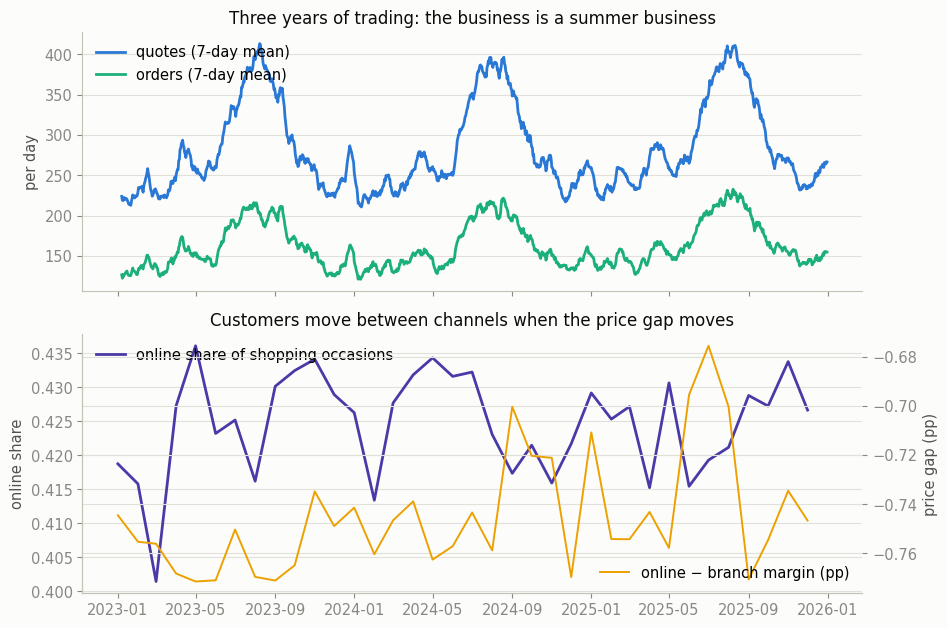

In [19]:
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, str(Path.cwd()))
from toolkit import C, INK, SUB, style, tidy

style()

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True)
by_day = daily.groupby("date")[["quotes", "orders"]].sum()
axes[0].plot(by_day.index, by_day["quotes"].rolling(7).mean(), color=C[0], label="quotes (7-day mean)")
axes[0].plot(by_day.index, by_day["orders"].rolling(7).mean(), color=C[1], label="orders (7-day mean)")
axes[0].set_title("Three years of trading: the business is a summer business")
axes[0].set_ylabel("per day")
axes[0].legend(loc="upper left")

share = q[q["region_id"] != "AIRPORT"].groupby(q["date"].dt.to_period("M").dt.to_timestamp())["chose_online"].mean()
gap = (board[board["zone"] == "ONLINE"].groupby(board["date"].dt.to_period("M").dt.to_timestamp())["our_margin_pp"].mean()
       - board[board["market"].eq("mainstream") & board["zone"].ne("ONLINE")]
       .groupby(board["date"].dt.to_period("M").dt.to_timestamp())["our_margin_pp"].mean())
axes[1].plot(share.index, share.values, color=C[4], label="online share of shopping occasions")
twin = axes[1].twinx()
twin.plot(gap.index, gap.values, color=C[2], lw=1.4, label="online − branch margin (pp)")
twin.set_ylabel("price gap (pp)", color=SUB)
axes[1].set_ylabel("online share")
axes[1].set_title("Customers move between channels when the price gap moves")
axes[1].legend(loc="upper left")
twin.legend(loc="lower right")
for ax in axes:
    tidy(ax)
plt.tight_layout()
plt.show()

In [20]:
checks = {
    "quotes": len(q),
    "transactions": len(txn),
    "conversion rate": round(q["converted"].mean(), 4),
    "customers who bought at least once": txn["customer_id"].nunique(),
    "orders per buying customer": round(len(txn) / txn["customer_id"].nunique(), 2),
    "turnover (GBP m)": round(txn["order_value_gbp"].sum() / 1e6, 2),
    "gross revenue (GBP k)": round(txn["gross_revenue_gbp"].sum() / 1e3, 1),
    "contribution (GBP k)": round(txn["contribution_gbp"].sum() / 1e3, 1),
    "contribution margin on revenue": round(txn["contribution_gbp"].sum() / txn["gross_revenue_gbp"].sum(), 3),
    "online share of occasions": round(float(q.loc[q["region_id"] != "AIRPORT", "chose_online"].mean()), 4),
    "click & collect share of online": round(float((txn["fulfilment"] == "click_collect").sum()
                                                   / max((txn["channel"] == "online").sum(), 1)), 4),
    "branch-days with a stockout": int(stock["stockout_flag"].sum()),
    "quotes in the A/B test": int(in_experiment.sum()),
    "complaint rate": round(txn["complaint"].mean(), 4),
}
for k, v in checks.items():
    print(f"{k:38s} {v:>12}")

CENTRAL_OVERHEAD_MONTH = 12000
fixed_year = sites["fixed_cost_month_gbp"].sum() * 12 + CENTRAL_OVERHEAD_MONTH * 12
print(f"\nannual fixed cost £{fixed_year:,.0f} vs annual contribution "
      f"£{txn['contribution_gbp'].sum() / 3:,.0f}  ->  operating profit "
      f"£{txn['contribution_gbp'].sum() / 3 - fixed_year:,.0f} a year")

print("\nrealised vs quoted margin (the selection gap, in pp), by channel:")
gap_table = daily.groupby("channel")[["avg_quoted_margin_pp", "avg_realised_margin_pp"]].mean()
gap_table["gap_pp"] = (gap_table["avg_realised_margin_pp"] - gap_table["avg_quoted_margin_pp"]).round(3)
print(gap_table.round(3).to_string())

quotes                                       309546
transactions                                 177656
conversion rate                              0.5739
customers who bought at least once            32259
orders per buying customer                     5.51
turnover (GBP m)                              84.99
gross revenue (GBP k)                        3127.5
contribution (GBP k)                         1816.2
contribution margin on revenue                0.581
online share of occasions                    0.4246
click & collect share of online              0.3841
branch-days with a stockout                    2269
quotes in the A/B test                         4082
complaint rate                               0.0109

annual fixed cost £504,000 vs annual contribution £605,398  ->  operating profit £101,398 a year

realised vs quoted margin (the selection gap, in pp), by channel:
         avg_quoted_margin_pp  avg_realised_margin_pp  gap_pp
channel                                      

Look at that last table for a moment, because it is a lesson in itself.

The **realised** margin — the one we actually earned, weighted by the orders
customers agreed to — sits *below* the margin we quoted, in every channel.
We never discounted a single transaction. The gap appears because the
customers most likely to say yes are the ones quoted the keenest rates, and
because larger orders (which carry more weight) shop harder.

Nobody decided this. It emerged from customers choosing. Every business has
a version of it, and the number in the "achieved price" box of a management
pack is almost never the number in the "list price" box. [Lab 1.1](../01_set_the_rate/lab_01_price_cost_and_profit.ipynb) turns
this into the **price waterfall**.

---

## What you have now

| Table | Grain | Use it for |
|---|---|---|
| `fct_quotes` | one shopping occasion | conversion models, channel choice, experiments, elasticity |
| `fct_transactions` | one order | revenue, cost, contribution, waterfalls, complaints |
| `fct_daily` | day × site × product | panel regressions, time series, reporting |
| `fct_region_week` | region × week, all channels | **geo experiments** ([the omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb)) |
| `fct_price_board` | day × zone × product | what we advertised, and why |
| `fct_competitor_prices` | day × competitor × zone × product | competitive analysis |
| `fct_stock` | branch-day × cash product | censoring and stockouts |
| `fct_customer_year` | one customer | retention, lifetime value |
| `fct_marketing` | month × region | demand shifter, regional confounder |
| `dim_*` | one per thing | joins, segments, cost stack |
| `truth.json` | — | marking your own homework |

## Practice

1. **Grain.** `fct_daily` has a column `avg_quoted_margin_pp`. If you take a
   plain `mean()` of that column across all rows, what exactly have you
   computed — and why is it not "our average margin"?
2. **Selection.** Online conversion is lower than branch conversion, *and*
   online is cheaper. Give two completely different explanations, one of
   which would lead you to raise online prices and one of which would not.
3. **Channel choice.** We raise the online rate by 40bp. Online volume falls
   8%. Branch volume in the same regions rises. What is the *total*
   business effect, and which of the three numbers you were just given is
   the least useful?

<details>
<summary>Answers</summary>

1. You have computed the **unweighted average of daily averages**: every
   day–site–product row counts the same, so a quiet Tuesday in a small
   branch counts as much as an August Saturday at Heathrow. Our actual
   average margin has to be weighted by the money it applied to — normally
   `sum(revenue) / sum(turnover)`. Unweighted means of ratios are the most
   common quiet error in commercial reporting.

2. (a) **Causal:** online customers are genuinely more price-sensitive —
   they are comparing four apps — so the same rate converts worse there.
   (b) **Selection:** the people who *choose* online are the ones who shop
   hardest, and our channel-choice model says exactly that. Under (a) the
   online price should probably come down; under (b) the low conversion is
   telling you about who is in the channel, not about the rate, and the
   correct response may be the opposite. Only a test that varies the online
   price for a random half of the *same* population separates them —
   [lab 2.4](lab_04_experiments_and_ab_testing.ipynb).

3. You cannot tell yet, and that is the point. Some of the branch rise is
   customers who switched channel — a transfer, not a gain — and until you
   measure at a level that contains both channels (the region), the two
   channel numbers are worse than useless because they look like a story.
   The least useful number is **online volume alone**: it is the one most
   likely to be quoted in a meeting and the one most contaminated by
   switching. [The omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb) builds the metric that fixes it.

</details>

---

**Next:** `02_price_cost_and_profit.ipynb` — the commercial arithmetic
everything else is built on.